# Digital Beamforming Architecture Trade Study

Where should a phased array digitize? Element-level digitization maximizes system dynamic range and beam flexibility, but pays for it in ADC count, beamformer data rate, and DC power. Subarray-level digitization cuts those costs at reduced dynamic range; a single analog-combined channel is cheapest of all.

This tutorial quantifies that trade with `phased-array-systems`:

1. define a wideband X-band comms scenario and requirements,
2. sweep digitization level, ADC resolution, beam count, and subarray size with a constraint-aware DOE,
3. check feasibility and extract the Pareto front,
4. explore the front interactively.

```bash
pip install "phased-array-systems[plotting]"
```

In [1]:
import warnings

warnings.filterwarnings("ignore")

from phased_array_systems.requirements import Requirement, RequirementSet
from phased_array_systems.scenarios import CommsLinkScenario
from phased_array_systems.trades import (
    BatchRunner,
    DesignSpace,
    extract_pareto,
    filter_feasible,
    generate_doe,
)

## 1. Scenario and requirements

A 200 MHz instantaneous-bandwidth X-band link at 50 km. The three `must` requirements pull in different directions: link margin wants aperture and power, system dynamic range wants many digitized channels (each adds 10·log10(N) of processing gain), and the prime power cap punishes exactly those channels.

In [2]:
scenario = CommsLinkScenario(
    freq_hz=10e9,
    bandwidth_hz=200e6,
    range_m=50e3,
    required_snr_db=10.0,
    rx_antenna_gain_db=30.0,
)

requirements = RequirementSet(
    requirements=[
        Requirement(
            id="REQ-001",
            name="Link margin",
            metric_key="link_margin_db",
            op=">=",
            value=3.0,
            severity="must",
        ),
        Requirement(
            id="REQ-002",
            name="System dynamic range",
            metric_key="dynamic_range_system_db",
            op=">=",
            value=80.0,
            severity="must",
        ),
        Requirement(
            id="REQ-003",
            name="Prime power",
            metric_key="prime_power_w",
            op="<=",
            value=6000.0,
            severity="must",
        ),
    ],
)

## 2. Design space and constraint-aware DOE

The digital architecture is the sweep: digitization level, ADC effective bits, beam count, and subarray size. `validate="architecture"` rejection-samples against the actual `Architecture` constructor, so the sub-array divisibility rules cannot produce dead cases in the batch.

In [3]:
space = (
    DesignSpace(name="DBF architecture")
    .add_variable("array.nx", "categorical", values=[32])
    .add_variable("array.ny", "categorical", values=[32])
    .add_variable("array.max_subarray_nx", "categorical", values=[4, 8, 16])
    .add_variable("array.max_subarray_ny", "categorical", values=[4, 8, 16])
    .add_variable("rf.tx_power_w_per_elem", "float", low=1.0, high=1.0)
    .add_variable("rf.rx_power_w_per_elem", "float", low=0.15, high=0.15)
    .add_variable(
        "digital.digitization_level",
        "categorical",
        values=["element", "subarray", "analog"],
    )
    .add_variable("digital.adc_enob", "float", low=8.0, high=14.0)
    .add_variable("digital.adc_jitter_ps_rms", "float", low=0.15, high=0.15)
    .add_variable("digital.n_beams", "categorical", values=[1, 4, 16])
    .add_variable("cost.cost_per_elem_usd", "float", low=200.0, high=200.0)
)

doe = generate_doe(space, method="lhs", n_samples=150, seed=42, validate="architecture")
runner = BatchRunner(scenario, requirements)
results = runner.run(doe, n_workers=1)
results[["digital.digitization_level", "digital.adc_enob", "digital.n_beams"]].head()

Running 150 cases (0 cached)


Completed 150 cases in 2.9s (0.019s/case)


,digital.digitization_level,digital.adc_enob,digital.n_beams
0,element,10.016186,16
1,analog,8.655632,16
2,analog,12.817559,16
3,subarray,11.794171,4
4,element,13.159902,16


## 3. Feasibility by digitization level

In [4]:
feasible = filter_feasible(results, requirements)
print(f"Feasible: {len(feasible)} / {len(results)}")

cols = [
    "dynamic_range_system_db",
    "bf_data_rate_gbps",
    "adc_power_w",
    "dsp_power_w",
    "prime_power_w",
]
feasible.groupby("digital.digitization_level")[cols].mean().round(1)

Feasible: 63 / 150


,dynamic_range_system_db,bf_data_rate_gbps,adc_power_w,dsp_power_w,prime_power_w
digital.digitization_level,,,,,
element,94.0,26267.8,152.3,498.5,5061.3
subarray,84.5,924.7,9.3,18.2,4313.4


The analog architecture never appears in the feasible set: a single digitized channel cannot reach the 80 dB system-dynamic-range floor. Subarray digitization clears it with roughly 1/30th the data rate of element-level, which buys its extra dynamic range with hundreds of watts of converter and beamformer power.

## 4. Pareto front: dynamic range vs prime power vs cost

In [5]:
pareto = extract_pareto(
    feasible,
    objectives=[
        ("dynamic_range_system_db", "maximize"),
        ("prime_power_w", "minimize"),
        ("cost_usd", "minimize"),
    ],
)
show = [
    "digital.digitization_level",
    "digital.adc_enob",
    "digital.n_beams",
    "array.max_subarray_nx",
    "dynamic_range_system_db",
    "bf_data_rate_gbps",
    "prime_power_w",
]
pareto[show].round(1).sort_values("prime_power_w").head(12)

,digital.digitization_level,digital.adc_enob,digital.n_beams,array.max_subarray_nx,dynamic_range_system_db,bf_data_rate_gbps,prime_power_w
118,subarray,12.6,4,16,80.4,240.0,4286.3
89,subarray,13.5,1,8,81.2,260.0,4286.5
136,subarray,13.7,1,8,81.3,260.0,4287.4
45,subarray,13.7,1,8,81.3,260.0,4287.4
3,subarray,11.8,4,4,81.7,440.0,4289.8
116,subarray,12.0,1,4,85.2,880.0,4291.2
85,subarray,11.9,1,4,87.9,1760.0,4300.9
48,subarray,13.2,1,4,90.1,2080.0,4322.8
10,element,10.4,1,8,93.9,25600.0,4462.6
74,element,10.5,1,8,94.4,25600.0,4467.5


## 5. Interactive exploration

With the `[plotting]` extra installed, the same data becomes an interactive figure — hover any point for its case id and metrics.

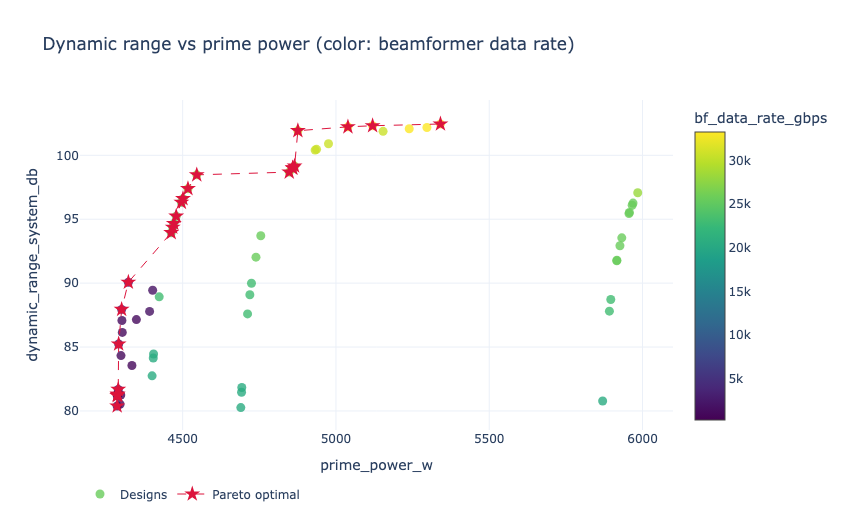

In [6]:
from phased_array_systems.viz.interactive import pareto_plot_interactive

front2d = extract_pareto(
    feasible,
    objectives=[
        ("prime_power_w", "minimize"),
        ("dynamic_range_system_db", "maximize"),
    ],
)
fig = pareto_plot_interactive(
    feasible,
    x="prime_power_w",
    y="dynamic_range_system_db",
    pareto_front=front2d,
    color_by="bf_data_rate_gbps",
    title="Dynamic range vs prime power (color: beamformer data rate)",
)
fig.show(renderer="png", width=850, height=520)

## Where to go next

- `examples/06_dbf_architecture_trade.py` runs this study as a script; `examples/configs/dbf_architecture_doe.yaml` runs it via `pasys doe`.
- The MDAO workflow tutorial replaces the DOE-derived front with an NSGA-II search and adds Sobol sensitivity.
- The docs' model-validation table lists the published reference behind every physics model used here.